# Modelado — Sartorius Cell Instance Segmentation-Cellpose
---
se realiza la ejecucion del modelo de cellpose


## 1. Librerías

In [1]:
import os, random, time, copy, warnings
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm import tqdm
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.cuda.amp import autocast, GradScaler
from torch.utils.data import DataLoader
from torchvision import models
import torchvision.transforms.functional as TF

# Métricas
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import ParameterGrid
from sartorius_utils import SartoriusDataset, preprocess, rle_decode

# ── Instalaciones necesarias (ejecutar una sola vez) ──────────────────────
# !pip install segmentation-models-pytorch timm cellpose
# !pip install git+https://github.com/facebookresearch/segment-anything.git

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {DEVICE}")
print(f"PyTorch: {torch.__version__}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")

Device : cuda
PyTorch: 2.8.0+cu128
GPU    : NVIDIA GeForce RTX 4050 Laptop GPU


## 2. Importar pipeline de preprocesamiento

Se reutilizan `config`, `SartoriusDataset`, el split 70/15/15 y los folds K-Fold  
definidos en `02_preprocesamiento.ipynb`.

In [2]:
def rle_decode(mask_rle: str, shape: tuple) -> np.ndarray:
    """
    Decodifica RLE a máscara binaria.
    mask_rle : string RLE (start length)
    shape    : (height, width)
    returns  : np.ndarray uint8 (h, w) con 0/1
    """
    s = list(map(int, mask_rle.split()))
    starts  = np.array(s[0::2]) - 1
    lengths = np.array(s[1::2])
    ends    = starts + lengths
    img = np.zeros(shape[0] * shape[1], dtype=np.uint8)
    for start, end in zip(starts, ends):
        img[start:end] = 1
    return img.reshape(shape)

In [3]:
# ── Carga del preprocesamiento exportado ─────────────────────────────────────
import joblib
import torch
from pathlib import Path

# ── Ruta del export ──────────────────────────────────────────────────────────
EXPORT_DIR  = Path("./preprocessing_exports")
EXPORT_FILE = EXPORT_DIR / "preprocessing_data.joblib"

# ── Verificación del archivo ────────────────────────────────────────────────
if not EXPORT_FILE.exists():
    raise FileNotFoundError(
        f"No se encontró el archivo:\n{EXPORT_FILE}\n"
        "Ejecuta primero el notebook de preprocesamiento."
    )

print("Archivo de preprocesamiento encontrado")

# ── Carga principal ─────────────────────────────────────────────────────────
data = joblib.load(EXPORT_FILE)

print("Export cargado correctamente")

# ── Recuperación de variables ───────────────────────────────────────────────
df_img         = data["df_img"]
df_train_base  = data["df_train_base"]
df_val         = data["df_val"]
df_test        = data["df_test"]

folds          = data["folds"]

config         = data["config"]
metadata       = data["metadata"]

# ── Device automático ───────────────────────────────────────────────────────
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"\n Device detectado: {DEVICE}")

if torch.cuda.is_available():
    print(f" GPU: {torch.cuda.get_device_name(0)}")

# ── Verificación de integridad ──────────────────────────────────────────────
required = [
    "df_img",
    "df_train_base",
    "df_val",
    "df_test",
    "folds",
    "config",
    "metadata"
]

missing = [k for k in required if k not in data]

if missing:
    raise ValueError(
        f"Faltan elementos en el export: {missing}"
    )

print("\n Integridad del export OK")

# ── Resumen del dataset ─────────────────────────────────────────────────────
print("\n──────── Dataset Summary ────────")
print(f"df_img        : {df_img.shape}")
print(f"df_train_base : {df_train_base.shape}")
print(f"df_val        : {df_val.shape}")
print(f"df_test       : {df_test.shape}")
print(f"folds         : {len(folds)}")

# ── Metadata entorno ────────────────────────────────────────────────────────
print("\n──────── Environment ───────────")
print(f"PyTorch       : {metadata['pytorch']}")
print(f"CUDA export   : {metadata['cuda']}")
print(f"Export device : {metadata['device']}")

# ── Configuración útil para DataLoader ──────────────────────────────────────
IMG_SIZE    = config["IMG_SIZE"]
MEAN        = config["MEAN"]
STD         = config["STD"]

PIN_MEMORY  = config["PIN_MEMORY"]
NUM_WORKERS = config["NUM_WORKERS"]

print("\n──────── Loader Config ─────────")
print(f"IMG_SIZE    : {IMG_SIZE}")
print(f"PIN_MEMORY  : {PIN_MEMORY}")
print(f"NUM_WORKERS : {NUM_WORKERS}")

# ── Nota importante ─────────────────────────────────────────────────────────
print(
    "\n Preprocesamiento cargado correctamente "
    "y listo para modelado."
)

Archivo de preprocesamiento encontrado
Export cargado correctamente

 Device detectado: cuda
 GPU: NVIDIA GeForce RTX 4050 Laptop GPU

 Integridad del export OK

──────── Dataset Summary ────────
df_img        : (606, 6)
df_train_base : (424, 6)
df_val        : (91, 6)
df_test       : (91, 6)
folds         : 5

──────── Environment ───────────
PyTorch       : 2.8.0+cu128
CUDA export   : True
Export device : NVIDIA GeForce RTX 4050 Laptop GPU

──────── Loader Config ─────────
IMG_SIZE    : (512, 512)
PIN_MEMORY  : True
NUM_WORKERS : 0

 Preprocesamiento cargado correctamente y listo para modelado.


## 3. Métricas de evaluación

Métrica principal de la competición: **mAP @ IoU 0.5:0.95** (Average Precision sobre instancias).  
Se implementan también IoU binario y Dice para monitoreo durante entrenamiento.

In [4]:
import numpy as np
import torch
from sklearn.metrics import roc_auc_score, balanced_accuracy_score
from scipy.spatial.distance import directed_hausdorff


# ════════════════════════════════════════════════════════════════════════════
# MÉTRICAS INDIVIDUALES
# ════════════════════════════════════════════════════════════════════════════

def dice_score(pred: torch.Tensor, true: torch.Tensor, eps=1e-6) -> float:
    pred = pred.bool().float()
    true = true.bool().float()
    return ((2 * (pred * true).sum() + eps) /
            (pred.sum() + true.sum() + eps)).item()


def iou_score(pred: torch.Tensor, true: torch.Tensor, eps=1e-6) -> float:
    pred = pred.bool()
    true = true.bool()
    return (((pred & true).float().sum() + eps) /
            ((pred | true).float().sum() + eps)).item()


def precision_score(pred: torch.Tensor, true: torch.Tensor, eps=1e-6) -> float:
    tp = (pred.bool() & true.bool()).float().sum()
    fp = (pred.bool() & ~true.bool()).float().sum()
    return ((tp + eps) / (tp + fp + eps)).item()


def recall_score(pred: torch.Tensor, true: torch.Tensor, eps=1e-6) -> float:
    tp = (pred.bool() & true.bool()).float().sum()
    fn = (~pred.bool() & true.bool()).float().sum()
    return ((tp + eps) / (tp + fn + eps)).item()


def auc_score(pred_prob: torch.Tensor, true: torch.Tensor) -> float:
    """
    AUC-ROC pixel-wise.
    pred_prob : probabilidades continuas en [0,1] (antes del umbral)
    true      : máscara binaria ground truth
    """
    y_true = true.bool().cpu().numpy().flatten().astype(int)
    y_prob = pred_prob.cpu().numpy().flatten()

    # Si solo hay una clase presente AUC no está definido
    if len(np.unique(y_true)) < 2:
        return float('nan')

    return roc_auc_score(y_true, y_prob)


def hausdorff_distance(pred: torch.Tensor, true: torch.Tensor) -> float:
    """
    Distancia de Hausdorff entre los bordes de pred y true.
    Retorna inf si alguna máscara está vacía.
    """
    pred_np = pred.bool().cpu().numpy()
    true_np = true.bool().cpu().numpy()

    pred_pts = np.argwhere(pred_np)
    true_pts = np.argwhere(true_np)

    if len(pred_pts) == 0 or len(true_pts) == 0:
        return float('inf')

    d1 = directed_hausdorff(pred_pts, true_pts)[0]
    d2 = directed_hausdorff(true_pts, pred_pts)[0]
    return max(d1, d2)


def balanced_accuracy(pred: torch.Tensor, true: torch.Tensor) -> float:
    """
    Balanced Accuracy pixel-wise.
    Corrige el desbalance natural fondo/célula (fondo >> célula en microscopía).
    """
    y_pred = pred.bool().cpu().numpy().flatten().astype(int)
    y_true = true.bool().cpu().numpy().flatten().astype(int)
    return balanced_accuracy_score(y_true, y_pred)


# ════════════════════════════════════════════════════════════════════════════
# CÁLCULO COMPLETO POR BATCH
# ════════════════════════════════════════════════════════════════════════════

def compute_all_metrics(pred_logits: torch.Tensor,
                         true_masks:  torch.Tensor,
                         threshold:   float = 0.5) -> dict:
    """
    Calcula las 7 métricas para un batch completo y retorna la media.

    Parámetros
    ----------
    pred_logits : (B, 1, H, W) — salida raw del modelo (sin sigmoid)
    true_masks  : (B, N, H, W) — máscaras de instancias ground truth
    threshold   : umbral de binarización

    Retorna
    -------
    dict con media de cada métrica sobre el batch
    """
    pred_prob = torch.sigmoid(pred_logits).squeeze(1).cpu()   # (B, H, W)
    pred_bin  = (pred_prob > threshold)                        # (B, H, W) bool
    true_bin  = (true_masks.sum(dim=1) > 0).cpu()             # (B, H, W) bool

    metrics = {
        'dice'              : [],
        'iou'               : [],
        'precision'         : [],
        'recall'            : [],
        'auc'               : [],
        'hausdorff'         : [],
        'balanced_accuracy' : [],
    }

    for p_prob, p_bin, t in zip(pred_prob, pred_bin, true_bin):
        metrics['dice'].append(dice_score(p_bin, t))
        metrics['iou'].append(iou_score(p_bin, t))
        metrics['precision'].append(precision_score(p_bin, t))
        metrics['recall'].append(recall_score(p_bin, t))
        metrics['auc'].append(auc_score(p_prob, t))
        metrics['hausdorff'].append(hausdorff_distance(p_bin, t))
        metrics['balanced_accuracy'].append(balanced_accuracy(p_bin, t))

    # Media ignorando NaN (AUC puede ser nan si la imagen es toda fondo)
    return {k: float(np.nanmean(v)) for k, v in metrics.items()}


# ════════════════════════════════════════════════════════════════════════════
# EVALUACIÓN COMPLETA — VALIDACIÓN Y TEST
# ════════════════════════════════════════════════════════════════════════════

@torch.no_grad()
def evaluate_full(model, loader, device, split_name='val') -> dict:
    """
    Evalúa el modelo sobre un DataLoader completo con las 7 métricas.

    Retorna dict con media y std de cada métrica sobre todo el split.
    """
    model.eval()

    accum = {
        'dice': [], 'iou': [], 'precision': [],
        'recall': [], 'auc': [], 'hausdorff': [],
        'balanced_accuracy': []
    }

    for batch in tqdm(loader, desc=f'  Evaluando [{split_name}]'):
        images = batch['image'].to(device)
        masks  = batch['masks']

        preds  = model(images)

        # Algunos modelos retornan dict (Mask R-CNN) — adaptar aquí si es necesario
        if isinstance(preds, dict):
            continue

        batch_metrics = compute_all_metrics(preds.cpu(), masks)

        for k, v in batch_metrics.items():
            accum[k].append(v)

    results = {}
    print(f'\n{"─"*45}')
    print(f'  Métricas — {split_name.upper()}')
    print(f'{"─"*45}')

    for metric, values in accum.items():
        clean  = [v for v in values if not np.isnan(v)]
        mean   = float(np.mean(clean))   if clean else float('nan')
        std    = float(np.std(clean))    if clean else float('nan')
        results[f'{metric}_mean'] = mean
        results[f'{metric}_std']  = std

        # Hausdorff en px, resto en [0,1]
        unit = ' px' if metric == 'hausdorff' else ''
        print(f'  {metric:<20}: {mean:.4f} ± {std:.4f}{unit}')

    print(f'{"─"*45}')
    return results


# ════════════════════════════════════════════════════════════════════════════
# VISUALIZACIÓN DE MÉTRICAS
# ════════════════════════════════════════════════════════════════════════════

def plot_metrics_comparison(results_dict: dict):
    """
    Gráfico de barras comparando las 7 métricas entre modelos.

    results_dict : {'NombreModelo': {'dice_mean': x, 'iou_mean': y, ...}, ...}
    """
    metrics_to_plot = ['dice', 'iou', 'precision', 'recall',
                        'auc', 'balanced_accuracy']
    hausdorff_vals  = {m: r.get('hausdorff_mean', 0)
                       for m, r in results_dict.items()}

    fig, axes = plt.subplots(1, 2, figsize=(18, 6),
                              gridspec_kw={'width_ratios': [3, 1]})
    fig.suptitle('Comparación de métricas por modelo', fontsize=14, fontweight='bold')

    # ── Panel izquierdo: métricas [0,1] ─────────────────────────────────────
    model_names = list(results_dict.keys())
    x     = np.arange(len(metrics_to_plot))
    width = 0.8 / len(model_names)
    colors = sns.color_palette('Set2', len(model_names))

    for i, (model_name, res) in enumerate(results_dict.items()):
        means = [res.get(f'{m}_mean', 0) for m in metrics_to_plot]
        stds  = [res.get(f'{m}_std',  0) for m in metrics_to_plot]
        offset = (i - len(model_names) / 2) * width + width / 2
        axes[0].bar(x + offset, means, width, yerr=stds,
                    label=model_name, color=colors[i],
                    capsize=3, alpha=0.85)

    axes[0].set_xticks(x)
    axes[0].set_xticklabels(
        ['Dice', 'IoU', 'Precision', 'Recall', 'AUC', 'Bal. Acc.'],
        fontsize=10
    )
    axes[0].set_ylim(0, 1.1)
    axes[0].set_ylabel('Score')
    axes[0].legend(loc='lower right')
    axes[0].set_title('Métricas en [0, 1]')

    # ── Panel derecho: Hausdorff (px, menor = mejor) ─────────────────────────
    hd_names  = list(hausdorff_vals.keys())
    hd_values = list(hausdorff_vals.values())
    axes[1].barh(hd_names, hd_values, color=colors[:len(hd_names)], alpha=0.85)
    axes[1].set_xlabel('Hausdorff Distance (px)')
    axes[1].set_title('Hausdorff ↓')
    for i, v in enumerate(hd_values):
        axes[1].text(v + 0.2, i, f'{v:.2f}', va='center', fontsize=9)

    plt.tight_layout()
    plt.savefig('metrics_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()


print('Métricas definidas')
print('  · dice_score          · iou_score')
print('  · precision_score     · recall_score')
print('  · auc_score           · hausdorff_distance')
print('  · balanced_accuracy   · compute_all_metrics')
print('  · evaluate_full       · plot_metrics_comparison')

Métricas definidas
  · dice_score          · iou_score
  · precision_score     · recall_score
  · auc_score           · hausdorff_distance
  · balanced_accuracy   · compute_all_metrics
  · evaluate_full       · plot_metrics_comparison


## 4. Grid de hiperparámetros

Hiperparámetros comunes que se ajustan en todos los modelos.  
Cada modelo puede sobreescribir los valores que no apliquen.

In [5]:
HYPERPARAM_GRID = {
    'learning_rate' : [1e-4, 5e-4, 1e-3],
    'batch_size'    : [2, 4],              # limitado por VRAM (imágenes 512x512)
    'epochs'        : [10, 20],
    'optimizer'     : ['adamw', 'sgd'],
    'scheduler'     : ['cosine', 'step', None],
}


def get_optimizer(name: str, params, lr: float):
    """Retorna el optimizador dado su nombre."""
    if name == 'adamw':
        return optim.AdamW(params, lr=lr, weight_decay=1e-4)
    elif name == 'adam':
        return optim.Adam(params, lr=lr)
    elif name == 'sgd':
        return optim.SGD(params, lr=lr, momentum=0.9, weight_decay=1e-4)
    raise ValueError(f'Optimizer desconocido: {name}')


def get_scheduler(name, optimizer, epochs: int, steps_per_epoch: int = 1):
    """Retorna el scheduler dado su nombre. None = sin scheduler."""
    if name == 'cosine':
        return optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    elif name == 'step':
        return optim.lr_scheduler.StepLR(optimizer, step_size=max(1, epochs//3), gamma=0.5)
    elif name == 'onecycle':
        return optim.lr_scheduler.OneCycleLR(
            optimizer, max_lr=optimizer.param_groups[0]['lr'],
            steps_per_epoch=steps_per_epoch, epochs=epochs
        )
    return None  # sin scheduler


print("Grid de hiperparámetros definido ")
total_combinations = (
    len(HYPERPARAM_GRID['learning_rate']) *
    len(HYPERPARAM_GRID['batch_size']) *
    len(HYPERPARAM_GRID['epochs']) *
    len(HYPERPARAM_GRID['optimizer'])
)

print(f"Combinaciones posibles: {total_combinations}")

Grid de hiperparámetros definido 
Combinaciones posibles: 24


## 5. Loop de entrenamiento genérico

Función reutilizable para todos los modelos. Registra pérdida e IoU por época  
y guarda el mejor modelo por validación.

In [6]:
def train_one_epoch(model, loader, optimizer, loss_fn, device):
    model.train()
    total_loss = 0.0
    for batch in tqdm(loader, desc='  train', leave=False):
        images = batch['image'].to(device)
        masks  = batch['masks'].to(device).float()
        optimizer.zero_grad()
        preds = model(images)
        loss  = loss_fn(preds, masks)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


@torch.no_grad()
def evaluate(model, loader, loss_fn, device):
    model.eval()
    total_loss, total_iou, total_dice = 0.0, 0.0, 0.0
    for batch in tqdm(loader, desc='  eval ', leave=False):
        images = batch['image'].to(device)
        masks  = batch['masks'].to(device).float()
        preds  = model(images)
        loss   = loss_fn(preds, masks)
        total_loss += loss.item()
        # IoU y Dice sobre primer canal (segmentación binaria)
        pred_bin = (torch.sigmoid(preds) > 0.5).squeeze(1)
        true_bin = (masks.sum(dim=1) > 0)
        for p, t in zip(pred_bin, true_bin):
            total_iou  += iou_score(p.cpu(), t.cpu())
            total_dice += dice_score(p.cpu(), t.cpu())
    n = len(loader.dataset)
    return total_loss/len(loader), total_iou/n, total_dice/n


def training_loop(model, ds_train, ds_val, hparams: dict,
                   loss_fn, model_name: str, device=DEVICE):
    """
    Loop completo: entrena, evalua por epoca, guarda mejor modelo.

    hparams esperados:
        learning_rate, batch_size, epochs, optimizer, scheduler (opcional)

    Retorna dict con historial de metricas y mejor modelo.
    """
    lr        = hparams['learning_rate']
    bs        = hparams['batch_size']
    epochs    = hparams['epochs']
    opt_name  = hparams['optimizer']
    sched_name = hparams.get('scheduler', None)

    loader_train = DataLoader(ds_train, batch_size=bs,
                          shuffle=True,  num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
    loader_val   = DataLoader(ds_val,   batch_size=bs,
                          shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

    model     = model.to(device)
    optimizer = get_optimizer(opt_name, model.parameters(), lr)
    scheduler = get_scheduler(sched_name, optimizer, epochs, len(loader_train))

    history = {'train_loss':[], 'val_loss':[], 'val_iou':[], 'val_dice':[]}
    best_iou, best_weights = 0.0, None

    print(f'\n[{model_name}] lr={lr} bs={bs} epochs={epochs} '
          f'opt={opt_name} sched={sched_name}')

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        train_loss               = train_one_epoch(model, loader_train, optimizer, loss_fn, device)
        val_loss, val_iou, val_dice = evaluate(model, loader_val, loss_fn, device)

        if scheduler:
            scheduler.step()

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_iou'].append(val_iou)
        history['val_dice'].append(val_dice)

        if val_iou > best_iou:
            best_iou     = val_iou
            best_weights = copy.deepcopy(model.state_dict())

        elapsed = time.time() - t0
        print(f'  Epoch {epoch:02d}/{epochs} | '
              f'train_loss={train_loss:.4f} | '
              f'val_loss={val_loss:.4f} | '
              f'val_iou={val_iou:.4f} | '
              f'val_dice={val_dice:.4f} | '
              f'{elapsed:.1f}s')

    model.load_state_dict(best_weights)
    print(f'  Mejor val_iou: {best_iou:.4f}')
    return model, history


def plot_history(history: dict, model_name: str):
    """Curvas de pérdida e IoU por época."""
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(f'{model_name} — Historial de entrenamiento', fontweight='bold')

    epochs = range(1, len(history['train_loss']) + 1)

    axes[0].plot(epochs, history['train_loss'], label='train')
    axes[0].plot(epochs, history['val_loss'],   label='val')
    axes[0].set_title('Loss'); axes[0].legend()

    axes[1].plot(epochs, history['val_iou'],  color='steelblue')
    axes[1].set_title('Val IoU')

    axes[2].plot(epochs, history['val_dice'], color='darkorange')
    axes[2].set_title('Val Dice')

    for ax in axes:
        ax.set_xlabel('Epoch')
    plt.tight_layout()
    plt.savefig(f'history_{model_name.lower().replace(" ","_")}.png',
                dpi=120, bbox_inches='tight')
    plt.show()


print("Loop de entrenamiento definido")

Loop de entrenamiento definido


---
## Modelo 1 — Cellpose 2.0

**Arquitectura:** modelo especializado en segmentación celular que predice  
flujos vectoriales (gradientes de distancia) en lugar de máscaras directas.  
Las instancias se reconstruyen siguiendo los flujos hacia el centro de cada célula.

**Por qué primero:** API propia altamente optimizada, no requiere loop PyTorch  
manual ni gestión de targets de instancia. El más rápido de ejecutar.  
Robusto ante células de muy distinto tamaño (`astro` vs `cort`).

Total combinaciones Cellpose: 4

COMBINACIÓN 1/4
{'batch_size': 4, 'cellprob_threshold': 0.0, 'chan': [0, 0], 'diameter': None, 'epochs': 50, 'flow_threshold': 0.4, 'img_size': 512, 'learning_rate': 0.01, 'model_type': 'cyto2', 'patience': 10}


Cargando Cellpose: 100%|██████████| 91/91 [00:02<00:00, 31.89it/s]


Entrenando 50 épocas completas...


100%|██████████| 91/91 [00:04<00:00, 20.01it/s]


Entrenamiento completo
Evaluando...


...

Entrenando 50 épocas completas...


100%|██████████| 91/91 [00:04<00:00, 19.35it/s]


Entrenamiento completo
Evaluando...


  Validación final: 100%|██████████| 91/91 [00:48<00:00,  1.89it/s]



 Resultado final | iou=0.5671 | dice=0.7097 | prec=0.8429 | rec=0.6544 | auc=0.8196 | bal_acc=0.8196
Nuevo mejor modelo guardado

MEJORES HIPERPARÁMETROS — Cellpose
{'batch_size': 8, 'cellprob_threshold': 0.0, 'chan': [0, 0], 'diameter': None, 'epochs': 50, 'flow_threshold': 0.4, 'img_size': 512, 'learning_rate': 0.1, 'model_type': 'cyto2', 'patience': 10}
Best Validation IoU: 0.5671


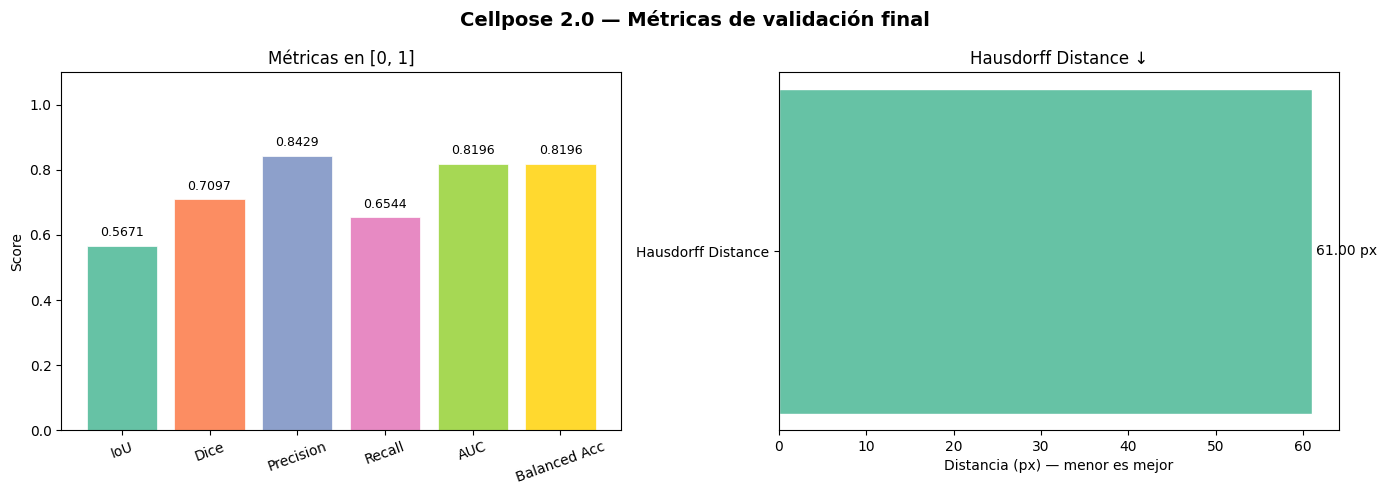

Figura guardada: metrics_cellpose_2.0.png


In [7]:
# ── Imports ───────────────────────────────────────────────────────────────
import os
import copy
import cv2
import torch
import numpy as np
import pandas as pd

from tqdm import tqdm
from sklearn.model_selection import ParameterGrid

from cellpose import models as cp_models
from cellpose import io as cp_io
from cellpose.transforms import normalize_img


# ── Grid Search Cellpose 2.2.3 ────────────────────────────────────────────
HPARAM_GRID_CELLPOSE = {
    'learning_rate'      : [0.01, 0.1],
    'batch_size'         : [4, 8],
    'epochs'             : [50],
    'flow_threshold'     : [0.4],
    'cellprob_threshold' : [0.0],
    'model_type'         : ['cyto2'],
    'diameter'           : [None],
    'chan'               : [[0, 0]],
    'img_size'           : [512],   
    'patience'           : [10],
}


# ── Utilidad de carga ─────────────────────────────────────────────────────
def load_for_cellpose(df_subset, img_size=512):
    images = []
    masks  = []

    for _, row in tqdm(
        df_subset.iterrows(),
        total=len(df_subset),
        desc='Cargando Cellpose'
    ):

        img = cv2.imread(row['ruta_imagen'])

        if img is None:
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        img = cv2.resize(
            img,
            (img_size, img_size),
            interpolation=cv2.INTER_LINEAR
        )

        inst_mask = np.zeros(
            (img_size, img_size),
            dtype=np.int32
        )

        for inst_id, rle in enumerate(row['rles'], start=1):

            if pd.isna(rle):
                continue

            mask = rle_decode(
                rle,
                (row['height'], row['width'])
            )

            mask = cv2.resize(
                mask.astype(np.uint8),
                (img_size, img_size),
                interpolation=cv2.INTER_NEAREST
            )

            inst_mask[mask > 0] = inst_id

        images.append(img)
        masks.append(inst_mask)

    return images, masks


# ── Entrenamiento compatible con Cellpose 2.2.3 ──────────────────────────
def train_cellpose(hparams, df_train_cp, df_val_cp):

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    img_size = hparams['img_size']

    train_imgs, train_masks = load_for_cellpose(df_train_cp, img_size=img_size)
    val_imgs,   val_masks   = load_for_cellpose(df_val_cp,   img_size=img_size)

    model = cp_models.CellposeModel(
        gpu        = torch.cuda.is_available(),
        model_type = hparams['model_type']
    )

    # ── Cellpose maneja su loop completo internamente ─────────────────────
    # NO llamar con n_epochs=1 en loop — el optimizador perdería su estado
    print(f'Entrenando {hparams["epochs"]} épocas completas...')

    model.train(
        train_data    = train_imgs,
        train_labels  = train_masks,
        test_data     = val_imgs,
        test_labels   = val_masks,
        channels      = hparams['chan'],
        learning_rate = hparams['learning_rate'],
        n_epochs      = hparams['epochs'],
        batch_size    = hparams['batch_size'],
        save_path     = './',
        save_every    = hparams['epochs'],   # guardar solo al final
        model_name    = 'cellpose_sartorius',
        normalize     = True,
        weight_decay  = 1e-5,
        momentum      = 0.9,
    )

    print('Entrenamiento completo')

    # ── Evaluación post-entrenamiento con las 7 métricas ──────────────────
    print('Evaluando...')

    val_metrics = {
        'iou': [], 'dice': [], 'precision': [],
        'recall': [], 'auc': [], 'hausdorff': [],
        'balanced_accuracy': []
    }

    for img, true_inst in tqdm(
    zip(val_imgs, val_masks),
    total = len(val_imgs),
    desc  = '  Validación final'
):
        try:
            eval_result = model.eval(
                [img],
                diameter           = hparams['diameter'],
                channels           = hparams['chan'],
                flow_threshold     = hparams['flow_threshold'],
                cellprob_threshold = hparams['cellprob_threshold']
            )
            masks_pred = eval_result[0]
            flows      = eval_result[1]

            pred_bin_np = (masks_pred[0] > 0).astype(np.uint8)
            true_bin_np = (true_inst > 0).astype(np.uint8)

            try:
                pred_prob_np = flows[2].copy()
                p_min, p_max = pred_prob_np.min(), pred_prob_np.max()
                pred_prob_np = (pred_prob_np - p_min) / (p_max - p_min + 1e-6)
            except Exception:
                pred_prob_np = pred_bin_np.astype(np.float32)

            pred_bin  = torch.from_numpy(pred_bin_np).bool()
            pred_prob = torch.from_numpy(pred_prob_np.astype(np.float32))
            true_bin  = torch.from_numpy(true_bin_np).bool()

            val_metrics['iou'].append(iou_score(pred_bin, true_bin))
            val_metrics['dice'].append(dice_score(pred_bin, true_bin))
            val_metrics['precision'].append(precision_score(pred_bin, true_bin))
            val_metrics['recall'].append(recall_score(pred_bin, true_bin))
            val_metrics['auc'].append(auc_score(pred_prob, true_bin))
            val_metrics['hausdorff'].append(hausdorff_distance(pred_bin, true_bin))
            val_metrics['balanced_accuracy'].append(balanced_accuracy(pred_bin, true_bin))

        except Exception as e:
            print(f'  Imagen omitida: {e}')
            continue

    results = {}
    for k, vals in val_metrics.items():
        if k == 'hausdorff':
            vals = [v for v in vals if v != float('inf')]
        results[k] = float(np.nanmean(vals)) if vals else np.nan

    mean_iou = results['iou']

    print(
        f'\n Resultado final | '
        f'iou={mean_iou:.4f} | '
        f'dice={results["dice"]:.4f} | '
        f'prec={results["precision"]:.4f} | '
        f'rec={results["recall"]:.4f} | '
        f'auc={results["auc"]:.4f} | '
        f'bal_acc={results["balanced_accuracy"]:.4f}'
    )

    return model, results, mean_iou

# ── Grid Search ───────────────────────────────────────────────────────────
grid = list(ParameterGrid(HPARAM_GRID_CELLPOSE))

print(f'Total combinaciones Cellpose: {len(grid)}')

best_model_cp      = None
best_history_cp    = None
best_hparams_cp    = None
best_global_iou_cp = 0.0


for idx, params in enumerate(grid):

    print('\n' + '=' * 70)
    print(f'COMBINACIÓN {idx + 1}/{len(grid)}')
    print(params)
    print('=' * 70)

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    model, results, current_iou = train_cellpose(
        params, df_train_base, df_val
    )

    if current_iou > best_global_iou_cp:
        best_global_iou_cp = current_iou
        best_model_cp      = model
        best_metrics_cp    = results
        best_hparams_cp    = params
        torch.save(
            best_model_cp.net.state_dict(),
            './cellpose_best.pth'
        )
        print('Nuevo mejor modelo guardado')

# ── Resultados finales ────────────────────────────────────────────────────
print('\n' + '=' * 70)
print('MEJORES HIPERPARÁMETROS — Cellpose')
print('=' * 70)
print(best_hparams_cp)
print(f'Best Validation IoU: {best_global_iou_cp:.4f}')

# ── Visualización adaptada para Cellpose ──────────────────────────────────
# Cellpose maneja su loop internamente → no hay historial por época
# Se visualizan las métricas finales del mejor modelo como barplot

def plot_cellpose_metrics(metrics: dict, model_name: str = 'Cellpose'):
    """
    Visualiza métricas finales de Cellpose como barplot.
    Reemplaza plot_history para modelos sin historial por época.
    """
    # Separar Hausdorff (escala distinta) del resto
    metrics_main = {
        'IoU'          : metrics.get('iou',               np.nan),
        'Dice'         : metrics.get('dice',              np.nan),
        'Precision'    : metrics.get('precision',         np.nan),
        'Recall'       : metrics.get('recall',            np.nan),
        'AUC'          : metrics.get('auc',               np.nan),
        'Balanced Acc' : metrics.get('balanced_accuracy', np.nan),
    }
    hausdorff = metrics.get('hausdorff', np.nan)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(
        f'{model_name} — Métricas de validación final',
        fontsize=14, fontweight='bold'
    )

    # ── Panel izquierdo: métricas [0,1] ──────────────────────────────────
    names  = list(metrics_main.keys())
    values = list(metrics_main.values())
    colors = sns.color_palette('Set2', len(names))

    bars = axes[0].bar(names, values, color=colors, edgecolor='white', linewidth=0.5)
    axes[0].set_ylim(0, 1.1)
    axes[0].set_ylabel('Score')
    axes[0].set_title('Métricas en [0, 1]')
    axes[0].tick_params(axis='x', rotation=20)

    for bar, val in zip(bars, values):
        if not np.isnan(val):
            axes[0].text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.02,
                f'{val:.4f}',
                ha='center', va='bottom', fontsize=9
            )

    # ── Panel derecho: Hausdorff ──────────────────────────────────────────
    axes[1].barh(
        ['Hausdorff Distance'],
        [hausdorff if not np.isnan(hausdorff) else 0],
        color=sns.color_palette('Set2', 1),
        edgecolor='white'
    )
    axes[1].set_xlabel('Distancia (px) — menor es mejor')
    axes[1].set_title('Hausdorff Distance ↓')

    if not np.isnan(hausdorff):
        axes[1].text(
            hausdorff + 0.5, 0,
            f'{hausdorff:.2f} px',
            va='center', fontsize=10
        )

    plt.tight_layout()
    plt.savefig(
        f'metrics_{model_name.lower().replace(" ", "_")}.png',
        dpi=150, bbox_inches='tight'
    )
    plt.show()
    print(f'Figura guardada: metrics_{model_name.lower().replace(" ", "_")}.png')


# ── Llamada ───────────────────────────────────────────────────────────────
plot_cellpose_metrics(best_metrics_cp, 'Cellpose 2.0')

In [8]:
# ── Guardado final de resultados Cellpose ────────────────────────────────
import json
import pickle

SAVE_DIR = './cellpose_results'
os.makedirs(SAVE_DIR, exist_ok=True)

# ── 1. Guardar pesos del mejor modelo ────────────────────────────────────
torch.save(
    best_model_cp.net.state_dict(),
    os.path.join(SAVE_DIR, 'cellpose_best_weights.pth')
)

print('Pesos guardados')

# ── 2. Guardar hiperparámetros ───────────────────────────────────────────
with open(
    os.path.join(SAVE_DIR, 'best_hparams.json'),
    'w'
) as f:
    json.dump(best_hparams_cp, f, indent=4)

print('Hiperparámetros guardados')

# ── 3. Guardar métricas ──────────────────────────────────────────────────
with open(
    os.path.join(SAVE_DIR, 'best_metrics.json'),
    'w'
) as f:
    json.dump(best_metrics_cp, f, indent=4)

print('Métricas guardadas')

# ── 4. Guardar objeto completo del modelo (opcional) ────────────────────
with open(
    os.path.join(SAVE_DIR, 'cellpose_model.pkl'),
    'wb'
) as f:
    pickle.dump(best_model_cp, f)

print('Modelo completo guardado')

print('\nTodo almacenado en:', SAVE_DIR)

Pesos guardados
Hiperparámetros guardados
Métricas guardadas
Modelo completo guardado

Todo almacenado en: ./cellpose_results
